In [ ]:
!rm -rf /content/drive
!mkdir /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'DR_New_Results', 'Dataset']


In [ ]:
# checkpoint_path defined here; actual load runs after model init
checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"
start_epoch = 0
# Actual loading happens in the post-model cell below

In [ ]:
!pip install timm imbalanced-learn
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import matplotlib.cm as cm

In [ ]:
import os

# =========================
# PATHS
# =========================
USE_DRIVE = True   # 🔥 Change to False if you don't want Drive

if USE_DRIVE:
    RESULT_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
else:
    RESULT_PATH = "/content/DR_New_Results/APTOS"

# =========================
# CREATE FOLDER
# =========================
os.makedirs(RESULT_PATH, exist_ok=True)

print("Saving results at:", RESULT_PATH)

Saving results at: /content/drive/MyDrive/DR_New_Results/APTOS


 **Reproducibility — Set Random Seed**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**APTOS Dataset Preprocessing**




In [ ]:
import os
import pandas as pd

# =========================
# DATASET PATH
# =========================
aptos_root = "/content/drive/MyDrive/Dataset/Full APTOS/2019"

csv_path = os.path.join(
    aptos_root,
    "train.csv"
)

# =========================
# LOAD CSV
# =========================
aptos_df = pd.read_csv(csv_path)

aptos_df.rename(
    columns={"diagnosis": "label"},
    inplace=True
)

# =========================
# IMAGE PATHS
# =========================
image_dict = {}

for root, _, files in os.walk(aptos_root):

    for file in files:

        if file.endswith(".png"):

            image_dict[
                os.path.splitext(file)[0]
            ] = os.path.join(root, file)

aptos_df["image_path"] = aptos_df[
    "id_code"
].map(image_dict)

# =========================
# REMOVE MISSING IMAGES
# =========================
aptos_df = aptos_df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

# =========================
# DONE
# =========================
print(
    "Dataset loaded:",
    len(aptos_df)
)

Dataset loaded: 3662


**Dataset Distribution Visualization Before Balancing**

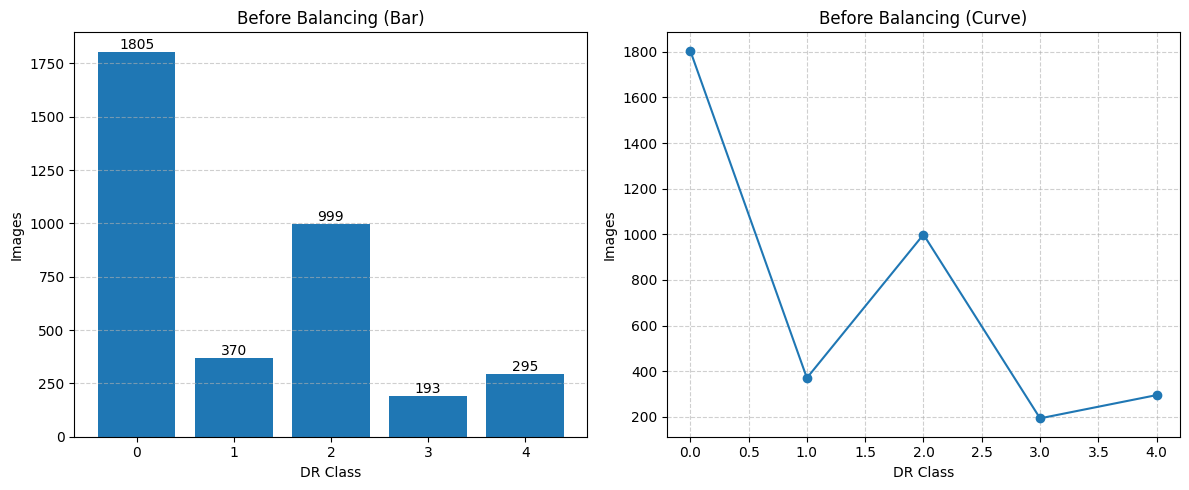


✅ Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/final_distribution_bar_curve.png


In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import matplotlib.pyplot as plt

# =========================
# COMPUTE CLASS DISTRIBUTION
# =========================
before_counts = aptos_df[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=10
        )

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.6
    )

# =========================
# VISUALIZE DISTRIBUTION
# =========================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

# BAR GRAPH
axes[0].bar(
    before_counts.index,
    before_counts.values
)

add_labels(axes[0])

style_plot(
    axes[0],
    "Before Balancing (Bar)"
)

# CURVE GRAPH
axes[1].plot(
    before_counts.index,
    before_counts.values,
    marker='o'
)

style_plot(
    axes[1],
    "Before Balancing (Curve)"
)

# =========================
# SAVE VISUALIZATION
# =========================
plt.tight_layout()

save_path = "/content/drive/MyDrive/DR_New_Results/APTOS/final_distribution_bar_curve.png"

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(
    f"\nSaved at: {save_path}"
)

**Visualization of Dataset Split Distribution**

Train: 2929
Validation: 366
Test: 367


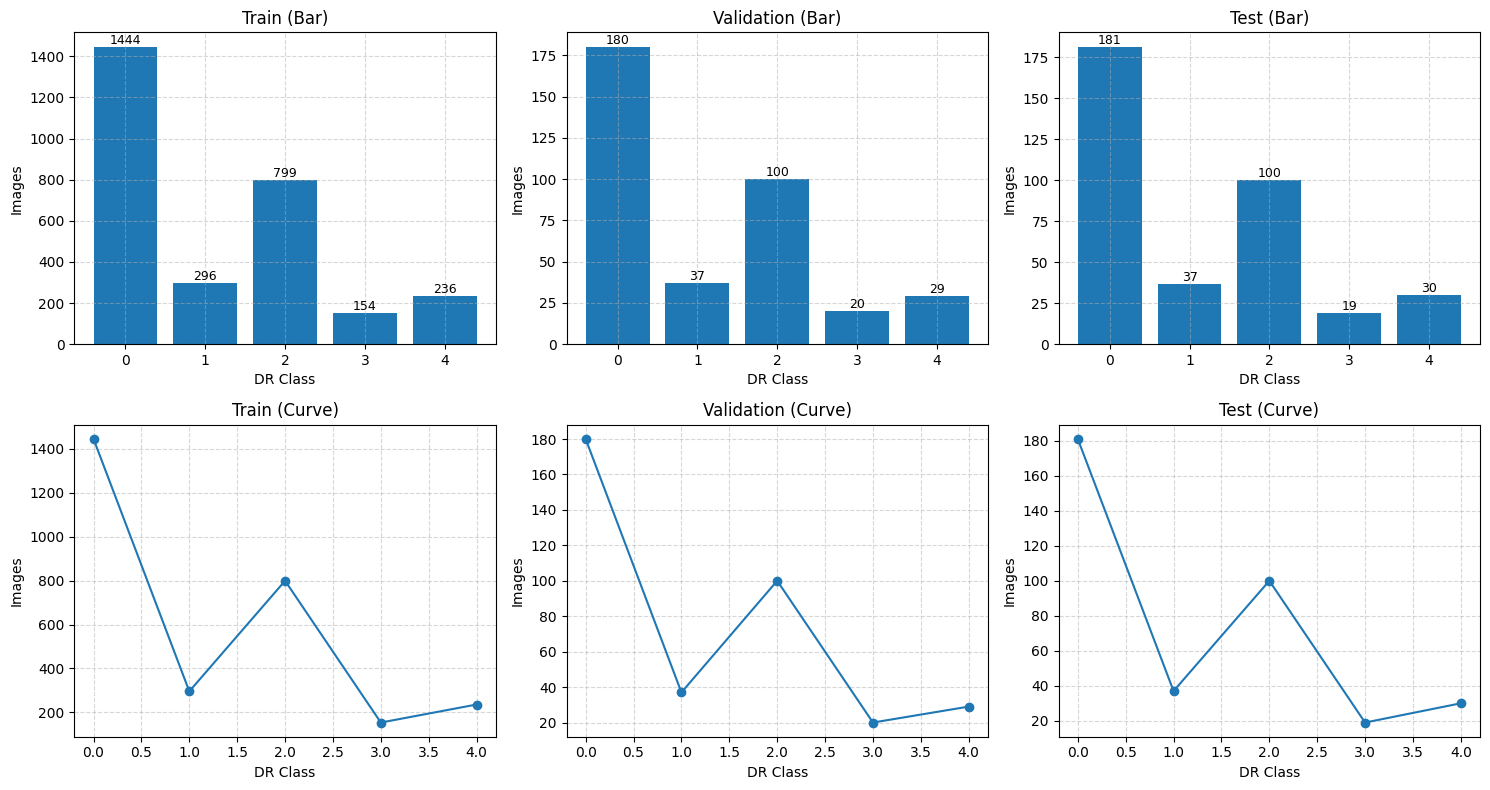


✅ Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/split_bar_and_curve_separate.png


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import os

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# =========================
# CREATE RESULT DIRECTORY
# =========================
base_path = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    base_path,
    exist_ok=True
)

# =========================
# SPLIT DATASET
# =========================
train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.2,
    stratify=aptos_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))

print("Validation:", len(val_df))

print("Test:", len(test_df))

# =========================
# COMPUTE CLASS DISTRIBUTION
# =========================
train_counts = train_df[
    "label"
].value_counts().sort_index()

val_counts = val_df[
    "label"
].value_counts().sort_index()

test_counts = test_df[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# VISUALIZE DISTRIBUTION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# ===== ROW 1: BAR =====
axes[0,0].bar(
    train_counts.index,
    train_counts.values
)

add_labels(axes[0,0])

style_plot(
    axes[0,0],
    "Train (Bar)"
)

axes[0,1].bar(
    val_counts.index,
    val_counts.values
)

add_labels(axes[0,1])

style_plot(
    axes[0,1],
    "Validation (Bar)"
)

axes[0,2].bar(
    test_counts.index,
    test_counts.values
)

add_labels(axes[0,2])

style_plot(
    axes[0,2],
    "Test (Bar)"
)

# ===== ROW 2: CURVE =====
axes[1,0].plot(
    train_counts.index,
    train_counts.values,
    marker='o'
)

style_plot(
    axes[1,0],
    "Train (Curve)"
)

axes[1,1].plot(
    val_counts.index,
    val_counts.values,
    marker='o'
)

style_plot(
    axes[1,1],
    "Validation (Curve)"
)

axes[1,2].plot(
    test_counts.index,
    test_counts.values,
    marker='o'
)

style_plot(
    axes[1,2],
    "Test (Curve)"
)

# =========================
# SAVE VISUALIZATION
# =========================
plt.tight_layout()

save_path = f"{base_path}/split_bar_and_curve_separate.png"

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(
    f"\nSaved at: {save_path}"
)

**Cleaned Dataset Split and Distribution Visualization**

Missing images (Train): 0
Missing images (Val): 0
Missing images (Test): 0

Final Sizes → Train: 2929 | Val: 366 | Test: 367


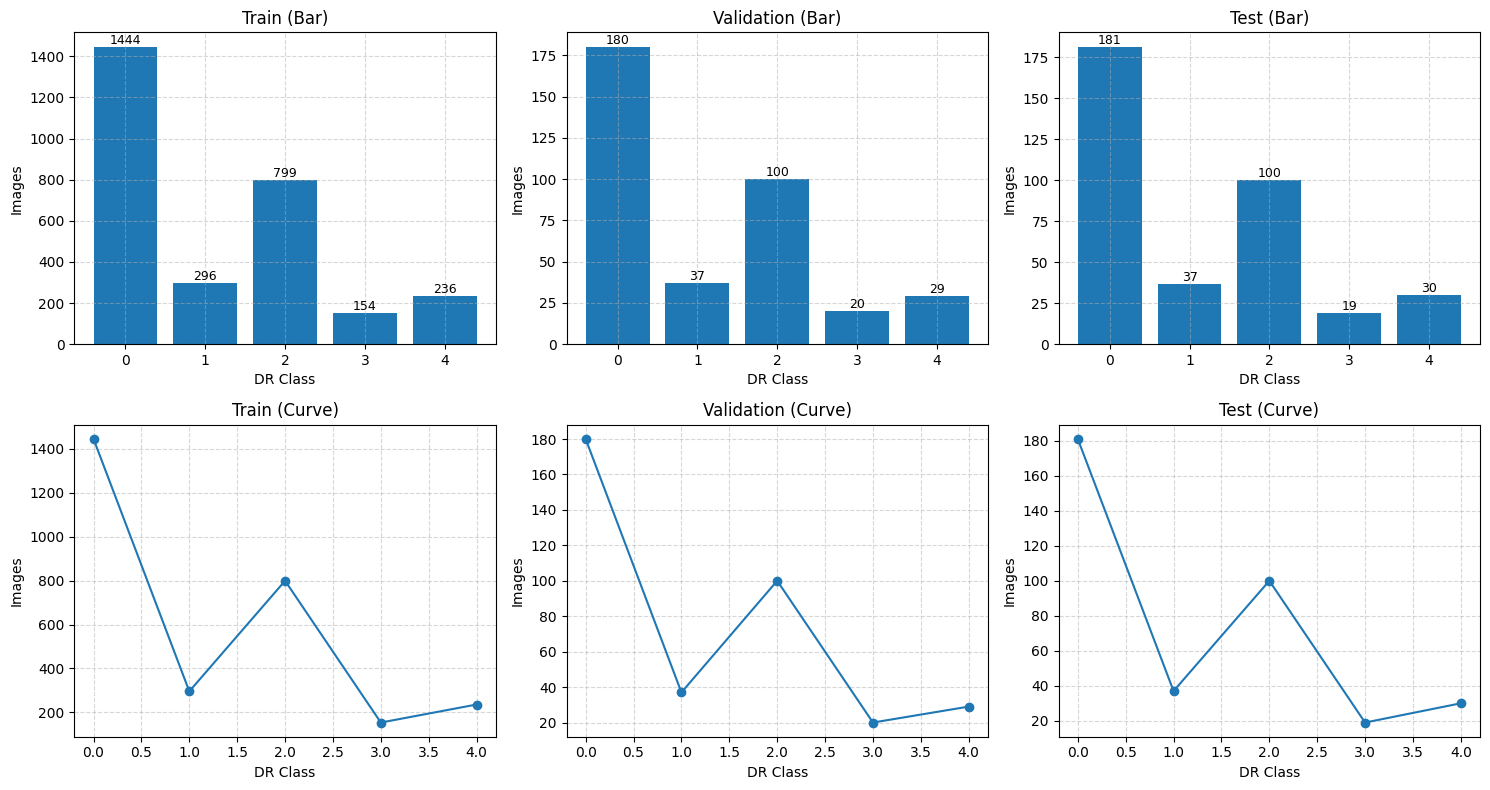


✅ Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/final_split_cleaned.png


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import os
import matplotlib.pyplot as plt

# =========================
# COPY DATAFRAMES
# =========================
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

datasets = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}

# =========================
# MAP IMAGE PATHS
# =========================
for name, df in datasets.items():

    df["image_path"] = df[
        "id_code"
    ].map(image_dict)

# =========================
# CHECK MISSING IMAGES
# =========================
for name, df in datasets.items():

    print(
        f"Missing images ({name}):",
        df["image_path"].isna().sum()
    )

# =========================
# CLEAN DATAFRAMES
# =========================
for name, df in datasets.items():

    df = df.dropna(
        subset=["image_path"]
    )

    df = df[
        df["image_path"].apply(os.path.exists)
    ]

    df["label"] = df[
        "label"
    ].astype(int)

    df = df.reset_index(drop=True)

    datasets[name] = df

# =========================
# UPDATE DATAFRAMES
# =========================
train_df = datasets["Train"]
val_df = datasets["Validation"]
test_df = datasets["Test"]

print(
    f"\nFinal Sizes → "
    f"Train: {len(train_df)} | "
    f"Val: {len(val_df)} | "
    f"Test: {len(test_df)}"
)

# =========================
# COMPUTE CLASS DISTRIBUTION
# =========================
train_counts = train_df[
    "label"
].value_counts().sort_index()

val_counts = val_df[
    "label"
].value_counts().sort_index()

test_counts = test_df[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# VISUALIZE DISTRIBUTION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# ===== BAR PLOTS =====
bar_data = [
    (train_counts, "Train (Bar)"),
    (val_counts, "Validation (Bar)"),
    (test_counts, "Test (Bar)")
]

for idx, (counts, title) in enumerate(bar_data):

    axes[0, idx].bar(
        counts.index,
        counts.values
    )

    add_labels(axes[0, idx])

    style_plot(
        axes[0, idx],
        title
    )

# ===== CURVE PLOTS =====
curve_data = [
    (train_counts, "Train (Curve)"),
    (val_counts, "Validation (Curve)"),
    (test_counts, "Test (Curve)")
]

for idx, (counts, title) in enumerate(curve_data):

    axes[1, idx].plot(
        counts.index,
        counts.values,
        marker='o'
    )

    style_plot(
        axes[1, idx],
        title
    )

# =========================
# SAVE VISUALIZATION
# =========================
plt.tight_layout()

save_path = "/content/drive/MyDrive/DR_New_Results/APTOS/final_split_cleaned.png"

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(
    f"\nSaved at: {save_path}"
)

**Imbalanced Dataset Visualization and Dataset Preparation**

Original (Imbalanced) Train Distribution:
label
0    1444
2     799
1     296
4     236
3     154
Name: count, dtype: int64


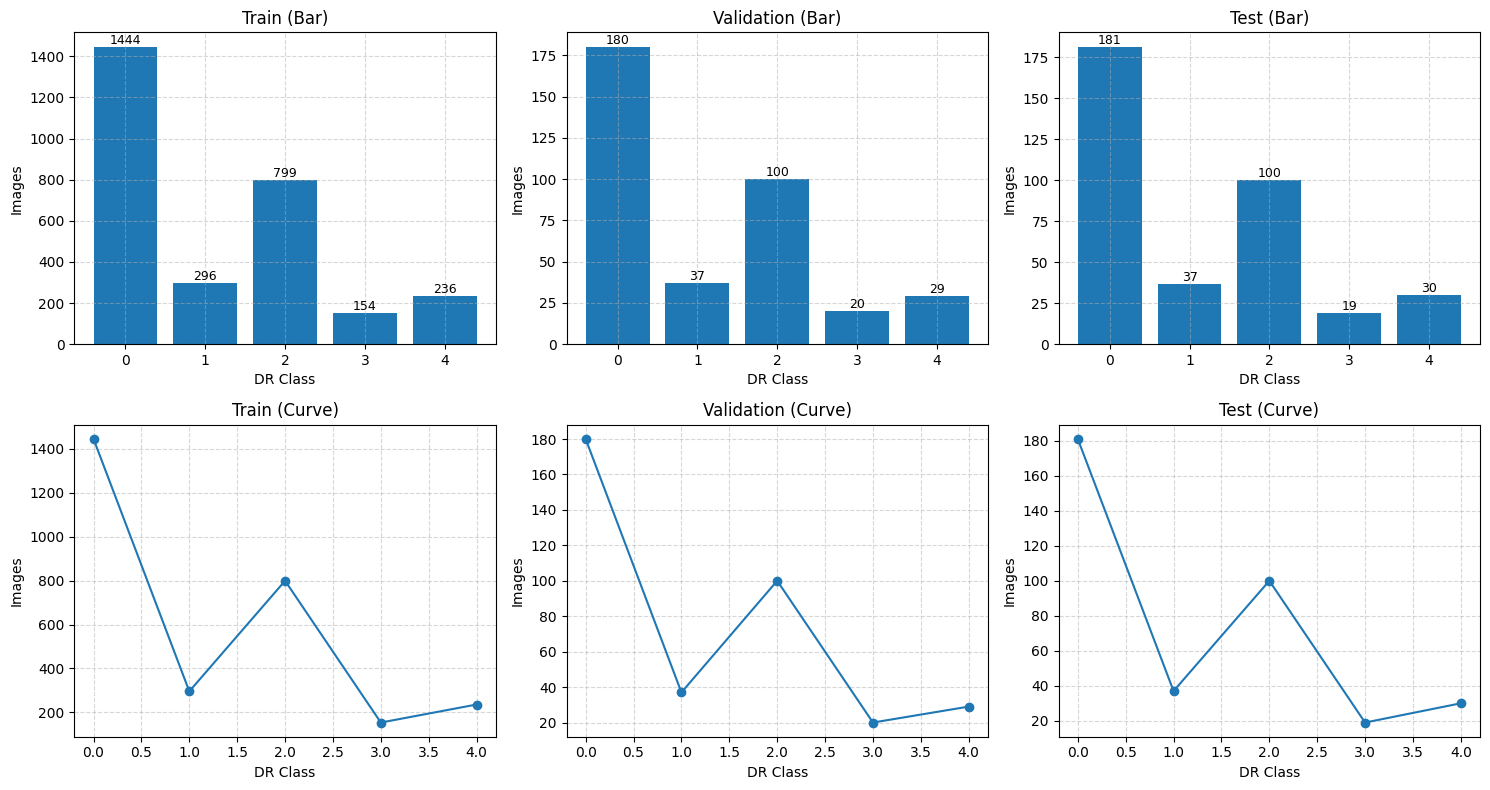


✅ Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/imbalanced_distribution.png


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import transforms

from PIL import Image

import torch

# =========================
# TRAIN DISTRIBUTION
# =========================
df = train_df.copy()

print("Original (Imbalanced) Train Distribution:")

print(
    df["label"].value_counts()
)

# =========================
# COMPUTE CLASS DISTRIBUTION
# =========================
train_counts = train_df[
    "label"
].value_counts().sort_index()

val_counts = val_df[
    "label"
].value_counts().sort_index()

test_counts = test_df[
    "label"
].value_counts().sort_index()

# =========================
# ADD VALUE LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        ax.annotate(
            f'{int(p.get_height())}',
            (
                p.get_x() + p.get_width()/2,
                p.get_height()
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# APPLY COMMON STYLING
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# =========================
# VISUALIZE DISTRIBUTION
# =========================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

# ===== BAR PLOTS =====
bar_data = [
    (train_counts, "Train (Bar)"),
    (val_counts, "Validation (Bar)"),
    (test_counts, "Test (Bar)")
]

for idx, (counts, title) in enumerate(bar_data):

    axes[0, idx].bar(
        counts.index,
        counts.values
    )

    add_labels(axes[0, idx])

    style_plot(
        axes[0, idx],
        title
    )

# ===== CURVE PLOTS =====
curve_data = [
    (train_counts, "Train (Curve)"),
    (val_counts, "Validation (Curve)"),
    (test_counts, "Test (Curve)")
]

for idx, (counts, title) in enumerate(curve_data):

    axes[1, idx].plot(
        counts.index,
        counts.values,
        marker='o'
    )

    style_plot(
        axes[1, idx],
        title
    )

# =========================
# SAVE VISUALIZATION
# =========================
plt.tight_layout()

save_path = "/content/drive/MyDrive/DR_New_Results/APTOS/imbalanced_distribution.png"

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print(
    f"\nSaved at: {save_path}"
)

# =========================
# DEFINE TRANSFORMS
# =========================
resize = transforms.Resize((320, 320))

normalize = transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)

train_transform = transforms.Compose([
    resize,
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    normalize
])

val_transform = transforms.Compose([
    resize,
    transforms.ToTensor(),
    normalize
])

# =========================
# CREATE DATASET CLASS
# =========================
class APTOSDataset(torch.utils.data.Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        try:

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

        except:

            image = Image.new(
                "RGB",
                (320,320)
            )

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# CREATE DATASETS
# =========================
train_dataset = APTOSDataset(
    train_df,
    transform=train_transform
)

val_dataset = APTOSDataset(
    val_df,
    transform=val_transform
)

test_dataset = APTOSDataset(
    test_df,
    transform=val_transform
)

**Augmentation and Data Preprocessing Configuration**

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
from torchvision import transforms

# =========================
# COMMON TRANSFORMS
# =========================
resize = transforms.Resize((320, 320))

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# =========================
# TRAIN TRANSFORM
# =========================
train_transform = transforms.Compose([

    resize,

    # Augmentation
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),

    transforms.ToTensor(),

    normalize
])

# =========================
# VALIDATION / TEST TRANSFORM
# =========================
val_transform = transforms.Compose([

    resize,

    transforms.ToTensor(),

    normalize
])

**Dataset Loader for APTOS Images**

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
from torch.utils.data import Dataset

from PIL import Image

import torch

# =========================
# APTOS DATASET CLASS
# =========================
class APTOSDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        while True:

            row = self.df.loc[idx]

            img_path = row["image_path"]

            label = int(row["label"])

            try:

                image = Image.open(
                    img_path
                ).convert("RGB")

                break

            except Exception:

                print(
                    f"Skipping corrupted image: {img_path}"
                )

                idx = (idx + 1) % len(self.df)

        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [ ]:
train_dataset = APTOSDataset(train_df, transform=train_transform)
val_dataset   = APTOSDataset(val_df, transform=val_transform)
test_dataset  = APTOSDataset(test_df, transform=val_transform)

**Training, Validation, and Test DataLoader Setup**

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
from torch.utils.data import DataLoader

import torch

# =========================
# DEVICE CONFIGURATION
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================
# DATALOADER SETTINGS
# =========================
if device.type == "cuda":

    batch_size = 16

    num_workers = 2

    pin_memory = True

else:

    batch_size = 8

    num_workers = 0

    pin_memory = False

persistent_workers = (
    num_workers > 0
)

# =========================
# COMMON LOADER PARAMETERS
# =========================
loader_kwargs = dict(

    batch_size=batch_size,

    num_workers=num_workers,

    pin_memory=pin_memory,

    persistent_workers=persistent_workers
)

# =========================
# CREATE DATALOADERS
# =========================
train_loader = DataLoader(

    train_dataset,

    shuffle=True,

    **loader_kwargs
)

val_loader = DataLoader(

    val_dataset,

    shuffle=False,

    **loader_kwargs
)

test_loader = DataLoader(

    test_dataset,

    shuffle=False,

    **loader_kwargs
)

**Proposed Model Architecture**

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import torch

import torch.nn as nn

from torchvision.models import (
    efficientnet_b4,
    EfficientNet_B4_Weights
)

# =========================
# CROSS PATCH ATTENTION
# =========================
class CrossPatchAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = in_channels // 8

        self.query = nn.Conv2d(
            in_channels,
            reduced_channels,
            1
        )

        self.key = nn.Conv2d(
            in_channels,
            reduced_channels,
            1
        )

        self.value = nn.Conv2d(
            in_channels,
            in_channels,
            1
        )

        self.scale = reduced_channels ** 0.5

    def forward(self, x):

        B, C, H, W = x.shape

        q = self.query(x).view(
            B,
            -1,
            H * W
        )

        k = self.key(x).view(
            B,
            -1,
            H * W
        )

        v = self.value(x).view(
            B,
            -1,
            H * W
        )

        attn = torch.bmm(
            q.permute(0,2,1),
            k
        ) / self.scale

        attn = torch.softmax(
            attn,
            dim=-1
        )

        out = torch.bmm(
            v,
            attn
        ).view(B, C, H, W)

        return out + x

# =========================
# REGION ATTENTION
# =========================
class RegionAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = in_channels // 4

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                reduced_channels,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                reduced_channels,
                in_channels,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        attn = self.conv(x)

        return x * attn

# =========================
# FINAL DR MODEL
# =========================
class DRModel(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        # Freeze early layers
        for param in self.features[:6].parameters():

            param.requires_grad = False

        in_channels = backbone.classifier[
            1
        ].in_features

        self.cross_attention = CrossPatchAttention(
            in_channels
        )

        self.region_attention = RegionAttention(
            in_channels
        )

        self.feat_drop = nn.Dropout2d(0.1)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(

            nn.LayerNorm(in_channels),

            nn.Linear(in_channels, 768),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.LayerNorm(768),

            nn.Linear(768, 512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.cross_attention(x)

        x = self.region_attention(x)

        x = self.feat_drop(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        return self.head(x)

**Model Training and Validation Pipeline**

In [ ]:
# =========================
# DEVICE CONFIGURATION
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# =========================
# RESULT PATH
# =========================
RESULT_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    RESULT_PATH,
    exist_ok=True
)

best_model_path = (
    f"{RESULT_PATH}/best_model.pth"
)

# =========================
# DATALOADER SETTINGS
# =========================
loader_kwargs = dict(

    batch_size=12,

    num_workers=2,

    pin_memory=True
)

# =========================
# CREATE DATALOADERS
# =========================
train_loader = DataLoader(

    train_dataset,

    shuffle=True,

    **loader_kwargs
)

val_loader = DataLoader(

    val_dataset,

    shuffle=False,

    **loader_kwargs
)

# =========================
# INITIALIZE MODEL
# =========================
model = DRModel(
    num_classes=5
).to(device)

# =========================
# COMPUTE CLASS WEIGHTS
# =========================
classes = np.unique(
    train_df["label"]
)

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=classes,

    y=train_df["label"]
)

weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

# =========================
# DEFINE FOCAL LOSS
# =========================
class FocalLoss(nn.Module):

    def __init__(self, gamma=2, weight=None):

        super().__init__()

        self.gamma = gamma

        self.weight = weight

    def forward(self, inputs, targets):

        ce_loss = nn.CrossEntropyLoss(

            weight=self.weight,

            reduction='none'

        )(inputs, targets)

        pt = torch.exp(-ce_loss)

        loss = (
            ((1 - pt) ** self.gamma)
            * ce_loss
        ).mean()

        return loss

criterion = FocalLoss(
    weight=weights
)

# =========================
# OPTIMIZER AND SCHEDULER
# =========================
optimizer = optim.AdamW(

    model.parameters(),

    lr=3e-5,

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20
)

# =========================
# AUTOMATIC MIXED PRECISION
# =========================
use_amp = (
    device.type == "cuda"
)

scaler = torch.cuda.amp.GradScaler(
    enabled=use_amp
)

# =========================
# TRAINING LOOP
# =========================
best_qwk = 0

num_epochs = 10

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(
            enabled=use_amp
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        train_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            # Test-Time Augmentation
            out1 = model(images)

            out2 = model(
                torch.flip(images, dims=[3])
            )

            outputs = (
                out1 + out2
            ) / 2

            preds = torch.argmax(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    qwk = cohen_kappa_score(

        all_labels,

        all_preds,

        weights='quadratic'
    )

    scheduler.step()

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"QWK: {qwk:.4f}")

    # ===== SAVE BEST MODEL =====
    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ Best model saved")

# =========================
# FINAL RESULT
# =========================
print(
    f"\nFINAL BEST QWK: {best_qwk:.4f}"
)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 96.9MB/s]
/tmp/ipykernel_9764/2707600744.py:91: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_9764/2707600744.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1/10
Train Loss: 265.5480
QWK: 0.5228
✓ Best model saved


/tmp/ipykernel_9764/2707600744.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 2/10
Train Loss: 225.3450
QWK: 0.6726
✓ Best model saved


...


Epoch 8/10
Train Loss: 158.1869
QWK: 0.7738


/tmp/ipykernel_9764/2707600744.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 9/10
Train Loss: 161.4824
QWK: 0.7713


/tmp/ipykernel_9764/2707600744.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 10/10
Train Loss: 160.1692
QWK: 0.7896
✓ Best model saved

🏆 FINAL BEST QWK: 0.7896


**Dataset Overlap Verification**

In [ ]:
train_set = set(train_df["image_path"])
val_set   = set(val_df["image_path"])
test_set  = set(test_df["image_path"])

print("Train-Val overlap:", len(train_set & val_set))
print("Train-Test overlap:", len(train_set & test_set))
print("Val-Test overlap:", len(val_set & test_set))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
common = set(train_df["id_code"]).intersection(set(val_df["id_code"]))
print("Common images:", len(common))

Common images: 0


**Test DataLoader Configuration**

In [ ]:
# =========================
# CREATE TEST DATALOADER
# =========================
test_dataset = APTOSDataset(
    test_df,
    val_transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=16,

    shuffle=False
)

**Model Evaluation on Test Set**

In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test QWK: {qwk:.4f}")

Test Accuracy: 0.6975
Test QWK: 0.8013


**Final Model Evaluation**


Accuracy : 0.6975
Precision: 0.7673
Recall   : 0.6975
F1 Score : 0.7095
QWK      : 0.8013

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       181
           1       0.36      0.70      0.48        37
           2       0.74      0.40      0.52       100
           3       0.23      0.53      0.32        19
           4       0.50      0.40      0.44        30

    accuracy                           0.70       367
   macro avg       0.56      0.59      0.54       367
weighted avg       0.77      0.70      0.71       367



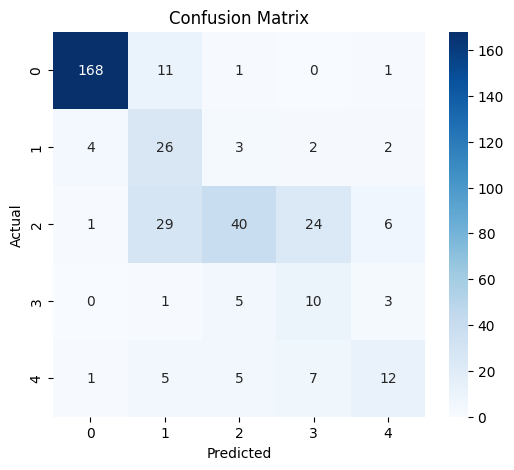


✅ Confusion matrix saved at: /content/drive/MyDrive/DR_New_Results/APTOS/confusion_matrix.png


In [ ]:
# =========================
# FINAL MODEL EVALUATION
# =========================

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(
    torch.load(best_model_path)
)

model.eval()

# =========================
# TEST PREDICTIONS
# =========================
y_true = []

y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

# =========================
# METRIC SETTINGS
# =========================
metric_kwargs = dict(
    average='weighted',
    zero_division=0
)

# =========================
# COMPUTE METRICS
# =========================
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    **metric_kwargs
)

recall = recall_score(
    y_true,
    y_pred,
    **metric_kwargs
)

f1 = f1_score(
    y_true,
    y_pred,
    **metric_kwargs
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

# =========================
# DISPLAY METRICS
# =========================
print(f"\nAccuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"QWK      : {qwk:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

# =========================
# SAVE CONFUSION MATRIX
# =========================
save_path = (
    "/content/drive/MyDrive/"
    "DR_New_Results/APTOS/confusion_matrix.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DISPLAY SAVE MESSAGE
# =========================
print(
    "\nConfusion matrix saved at:",
    save_path
)

**Result Saving Pipeline**

In [ ]:
# =========================
# RESULT SAVING PIPELINE
# =========================

# =========================
# RESULT PATH
# =========================
RESULTS_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    RESULTS_PATH,
    exist_ok=True
)

# =========================
# SAVE ALL RESULTS
# =========================
def save_all_results(

    y_true,

    y_pred,

    accuracy,

    precision,

    recall,

    f1,

    kappa,

    save_path
):

    os.makedirs(
        save_path,
        exist_ok=True
    )

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues"
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.title("Confusion Matrix")

    plt.savefig(
        os.path.join(
            save_path,
            "confusion_matrix.png"
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    # =========================
    # METRICS TABLE
    # =========================
    metrics_data = [

        ["Accuracy", f"{accuracy:.4f}"],

        ["Precision", f"{precision:.4f}"],

        ["Recall", f"{recall:.4f}"],

        ["F1-Score", f"{f1:.4f}"],

        ["QWK", f"{kappa:.4f}"]
    ]

    fig, ax = plt.subplots()

    ax.axis('off')

    ax.table(

        cellText=metrics_data,

        colLabels=["Metric", "Value"],

        loc='center'
    )

    plt.savefig(
        os.path.join(
            save_path,
            "evaluation_metrics.png"
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    # =========================
    # CLASSIFICATION REPORT
    # =========================
    report = classification_report(
        y_true,
        y_pred,
        zero_division=0
    )

    fig, ax = plt.subplots(
        figsize=(8,6)
    )

    ax.axis('off')

    ax.text(
        0,
        1,
        report,
        fontsize=10,
        family='monospace'
    )

    plt.savefig(
        os.path.join(
            save_path,
            "classification_report.png"
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    # =========================
    # PREDICTION DISTRIBUTION
    # =========================
    plt.figure(figsize=(6,4))

    plt.hist(
        y_pred,
        bins=np.arange(6)-0.5,
        rwidth=0.8
    )

    plt.xticks(range(5))

    plt.xlabel("Predicted Class")

    plt.ylabel("Frequency")

    plt.title("Prediction Distribution")

    plt.savefig(
        os.path.join(
            save_path,
            "prediction_distribution.png"
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    # =========================
    # FINAL MESSAGE
    # =========================
    print(
        f"All results saved in: {save_path}"
    )

# =========================
# EXECUTE RESULT SAVING
# =========================
save_all_results(

    y_true,

    y_pred,

    accuracy,

    precision,

    recall,

    f1,

    qwk,

    RESULTS_PATH
)

✅ All results saved in: /content/drive/MyDrive/DR_New_Results/APTOS


**Ablation Study**


Training: Baseline

Training: Baseline + Cross

Training: Baseline + Region

Training: Baseline + Cross + Region

Final Ablation Results:
                        Model     QWK  Accuracy  F1-Score  Params (M)
0    Baseline (EfficientNet)  0.8159    0.7432    0.7409       17.56
1           Baseline + Cross  0.8089    0.7186    0.7116       19.71
2          Baseline + Region  0.7649    0.6995    0.6961       23.72
3  Baseline + Cross + Region  0.8008    0.7377    0.7276       27.74


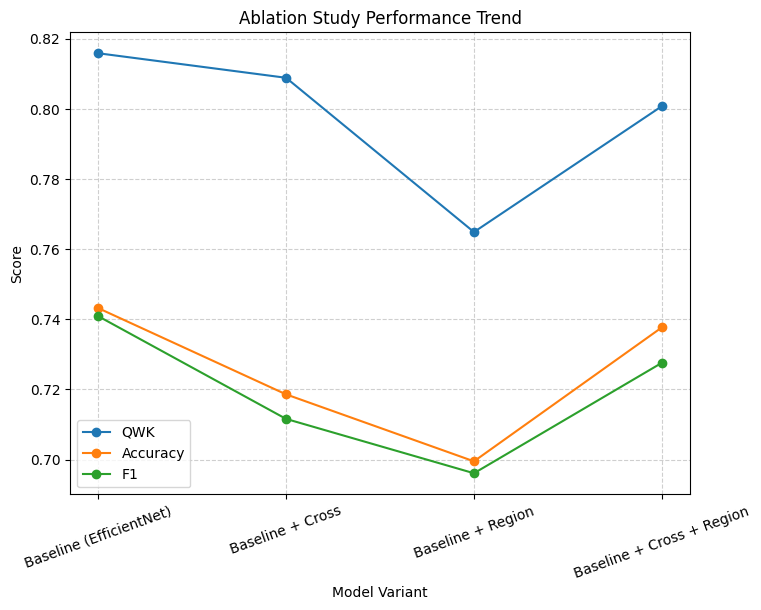


✅ CSV saved at: /content/drive/MyDrive/DR_New_Results/APTOS/ablation/ablation_results_final.csv
✅ Table saved at: /content/drive/MyDrive/DR_New_Results/APTOS/ablation/ablation_table_final.png
✅ Curve saved at: /content/drive/MyDrive/DR_New_Results/APTOS/ablation/ablation_curve_final.png


In [ ]:
# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================
# SAVE PATH
# =========================
SAVE_PATH = (
    "/content/drive/MyDrive/"
    "DR_New_Results/APTOS/ablation"
)

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# =========================
# PARAMETER COUNT
# =========================
def count_params(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

# =========================
# TRAIN FUNCTION
# =========================
def train_model(model, epochs=5):

    model = model.to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=3e-5
    )

    criterion = nn.CrossEntropyLoss(
        weight=weights
    )

    # ===== TRAIN =====
    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

    # ===== VALIDATION =====
    model.eval()

    preds = []

    true = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            p = torch.argmax(
                outputs,
                1
            ).cpu().numpy()

            preds.extend(p)

            true.extend(labels.numpy())

    qwk = cohen_kappa_score(
        true,
        preds,
        weights='quadratic'
    )

    acc = accuracy_score(
        true,
        preds
    )

    f1 = f1_score(
        true,
        preds,
        average='weighted'
    )

    return qwk, acc, f1

# =========================
# MODEL VARIANTS
# =========================
class BaselineModel(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        backbone = models.efficientnet_b4(
            weights="IMAGENET1K_V1"
        )

        self.features = backbone.features

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(
            1792,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x).flatten(1)

        return self.fc(x)

class CrossModel(DRModel):

    def __init__(self):

        super().__init__()

        self.region_attention = nn.Identity()

class RegionModel(DRModel):

    def __init__(self):

        super().__init__()

        self.cross_attention = nn.Identity()

class FullModel(DRModel):

    def __init__(self):

        super().__init__()

# =========================
# RUN ABLATION
# =========================
results = []

models_dict = {

    "Baseline": BaselineModel(),

    "Baseline + Cross": CrossModel(),

    "Baseline + Region": RegionModel(),

    "Baseline + Cross + Region": FullModel()
}

for name, model in models_dict.items():

    print(f"\nTraining: {name}")

    qwk, acc, f1 = train_model(
        model,
        epochs=5
    )

    params = count_params(model) / 1e6

    results.append({

        "Model": name,

        "QWK": round(qwk, 4),

        "Accuracy": round(acc, 4),

        "F1-Score": round(f1, 4),

        "Params (M)": round(params, 2)
    })

# =========================
# CREATE RESULT TABLE
# =========================
df = pd.DataFrame(results)

df["Model"] = df["Model"].replace({

    "Baseline":
    "Baseline (EfficientNet)"
})

order = [

    "Baseline (EfficientNet)",

    "Baseline + Cross",

    "Baseline + Region",

    "Baseline + Cross + Region"
]

df["Model"] = pd.Categorical(

    df["Model"],

    categories=order,

    ordered=True
)

df = df.sort_values("Model")

print("\nFinal Ablation Results:\n")

print(df)

# =========================
# SAVE CSV
# =========================
csv_path = os.path.join(
    SAVE_PATH,
    "ablation_results_final.csv"
)

df.to_csv(
    csv_path,
    index=False
)

# =========================
# SAVE TABLE IMAGE
# =========================
fig, ax = plt.subplots(figsize=(10,4))

ax.axis('off')

table = ax.table(

    cellText=df.values,

    colLabels=df.columns,

    loc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(1, 2)

table_path = os.path.join(
    SAVE_PATH,
    "ablation_table_final.png"
)

plt.savefig(
    table_path,
    dpi=300,
    bbox_inches='tight'
)

plt.close()

# =========================
# PERFORMANCE CURVE
# =========================
plt.figure(figsize=(8,6))

metrics = [

    "QWK",

    "Accuracy",

    "F1-Score"
]

for metric in metrics:

    plt.plot(
        df["Model"],
        df[metric],
        marker='o',
        label=metric
    )

plt.title(
    "Ablation Study Performance Trend"
)

plt.xlabel("Model Variant")

plt.ylabel("Score")

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.xticks(rotation=20)

plt.legend()

curve_path = os.path.join(
    SAVE_PATH,
    "ablation_curve_final.png"
)

plt.savefig(
    curve_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================
# FINAL MESSAGE
# =========================
print(f"\nCSV saved at: {csv_path}")

print(f"Table saved at: {table_path}")

print(f"Curve saved at: {curve_path}")